# РГР



In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats


def process_dataset(data, column_name, is_normal=False):
    n = len(data)
    print(f"Объём выборки: n = {len(data)}")
    print()

    sorted_data = sorted(data)

    x_bar = sum(data) / n       # среднее
    s2 = sum((x - x_bar)**2 for x in data) / n          # дисперсия (смещённая!)
    s2_un = sum((x - x_bar)**2 for x in data) / (n - 1)          # дисперсия (несмещённая!)
    s = s2 ** 0.5           # стандартное отклонение
    s_un = s2_un ** 0.5
    median = sorted_data[n // 2] if n % 2 == 1 else (sorted_data[n // 2 - 1] + sorted_data[n // 2]) / 2      # медиана
    x_min = sorted_data[0]       # минимум
    x_max = sorted_data[n - 1]       # максимум

    q1 = np.quantile(data, 0.25)
    q2 = np.quantile(data, 0.5)
    q3 = np.quantile(data, 0.75)

    skewness = (
            sum((x - x_bar)**3 for x in data) / n
        ) / (s**3)
    print("Выборочные оценки:")
    print(f"  Среднее:      x̄ = {x_bar:.2f}")
    print(f"  Дисперсия(смещенная):    s² = {s2:.2f}")
    print(f"  Ст. откл. (смещенное):    s = {s:.2f}")
    print(f"  Дисперсия(несмещенная):    s² = {s2_un:.2f}")
    print(f"  Ст. откл. (несмещенное):    s = {s_un:.2f}")
    print(f"  Медиана:      x̃ = {median:.2f}")
    print(f"  Размах:       [{x_min:.1f}, {x_max:.1f}]")
    print(f"  Квартили:")
    print(f"    {q1 = }")
    print(f"    {q2 = }")
    print(f"    {q3 = }")
    print(f"  Коэффициент ассиметрии:  \u03B3 = {skewness}  ")
    print()

    h_Skott = 3.5 * s * n**(-1/3)
    k_Skott = math.ceil((x_max - x_min) / h_Skott)

    print(f"Правило Скотта:")
    print(f"  Ширина интервала: h = {h_Skott:.2f}")
    print(f"  Число интервалов: k = {k_Skott}")
    print()

    iqr = q3 - q1
    h_Fridman = 2 * iqr * n **(-1/3)
    k_Fridman = math.ceil((x_max - x_min) / h_Fridman)
    print(f"Правило Фридмана–Диакониса:")
    print(f"  Ширина интервала: h = {h_Fridman:.2f}")
    print(f"  Число интервалов: k = {k_Fridman}")
    print()

    k_Sterdges = math.ceil(1 + math.log(n, 2))
    print(f"Правило Стерджеса:")
    print(f"  Число интервалов: k = {k_Sterdges}")
    print()

    plt.figure(figsize=(12, 10))

    for i, bincount in enumerate([k_Skott, k_Fridman, k_Sterdges]):
        ax = plt.subplot(2, 2, i + 1)

        ax.hist(sorted_data, bins=bincount, edgecolor="black")
        ax.axvline(x_bar, color="red", linestyle="--", 
                linewidth=2, label=f"Среднее значение = {x_bar:.2f}")
        ax.legend()

        ax.set_title(f"Гистограмма с числом интервалов k = {bincount}", size=12)

    plt.tight_layout()
    plt.show()

    # --- 4.5. Оценка моментов по сгруппированной выборке ---
    print("\n" + "="*60)
    print("4.5. ОЦЕНКА МОМЕНТОВ ПО СГРУППИРОВАННОЙ ВЫБОРКЕ")
    print("="*60)
    
    # Используем правило Стерджеса для группировки [cite: 100]
    k_group = k_Sterdges
    counts, bin_edges = np.histogram(sorted_data, bins=k_group)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    print(f"\nГруппировка по правилу Стерджеса (k = {k_group}):")
    print("  Интервал              Частота  Середина интервала")
    print("  " + "-"*50)
    for i in range(k_group):
        print(f"  [{bin_edges[i]:>8.2f}; {bin_edges[i+1]:>8.2f})    {counts[i]:>6}    {bin_centers[i]:>10.2f}")
    
    # Среднее по сгруппированным данным [cite: 136]
    x_bar_grouped = np.sum(counts * bin_centers) / n
    
    # Исправленная дисперсия по сгруппированным данным [cite: 136]
    s2_grouped = np.sum(counts * (bin_centers - x_bar_grouped) ** 2) / (n - 1)
    
    print(f"\nОценки по сгруппированной выборке:")
    print(f"  EX (среднее) = {x_bar_grouped:.4f}")
    print(f"  DX (дисперсия, исправленная) = {s2_grouped:.4f}")
    print(f"  СКО (по сгруппированным) = {np.sqrt(s2_grouped):.4f}")
    
    print(f"\nСравнение с оценками по исходным данным:")
    print(f"  Среднее: {x_bar:.4f} (исходное) vs {x_bar_grouped:.4f} (группированное)")
    print(f"  Разница: {abs(x_bar - x_bar_grouped):.6f}")
    print(f"  Дисперсия: {s2_un:.4f} (исходная) vs {s2_grouped:.4f} (группированная)")
    print(f"  Разница: {abs(s2_un - s2_grouped):.6f}")
    
    # --- 4.6. Доверительные интервалы ---
    print("\n" + "="*60)
    print("4.6. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (γ = 0.95)")
    print("="*60)
    
    gamma = 0.95
    alpha = 1 - gamma
    
    # 1. Асимптотический доверительный интервал для EX (по ЦПТ) [cite: 139]
    z_val = stats.norm.ppf(1 - alpha / 2)
    std_error = s_un / np.sqrt(n)
    ci_asymptotic = (x_bar - z_val * std_error, x_bar + z_val * std_error)
    
    print(f"\n1. Асимптотический ДИ для EX (по ЦПТ) для столбца {column_name}:")
    print(f"   Формула: x̄ ± z_{{1-α/2}} · s/√n")
    print(f"   z_{{0.975}} = {z_val:.4f}")
    print(f"   s/√n = {std_error:.4f}")
    print(f"   ДИ = ({ci_asymptotic[0]:.4f}; {ci_asymptotic[1]:.4f})")
    print(f"   Длина интервала: {ci_asymptotic[1] - ci_asymptotic[0]:.4f}")
    
    results = {
        "grouped_mean": x_bar_grouped,
        "grouped_var": s2_grouped,
        "ci_asymptotic": ci_asymptotic
    }
    
    # 2. Точные доверительные интервалы для нормального распределения
    if is_normal:
        t_val = stats.t.ppf(1 - alpha / 2, df=n - 1)
        chi2_low = stats.chi2.ppf(alpha / 2, df=n - 1)
        chi2_high = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
        
        # Точный ДИ для µ при неизвестной σ² [cite: 140]
        ci_mu_exact = (
            x_bar - t_val * (s_un / np.sqrt(n)),
            x_bar + t_val * (s_un / np.sqrt(n))
        )
        
        # Точный ДИ для σ² [cite: 145]
        ci_sigma_sq = (
            (n - 1) * s2_un / chi2_high,
            (n - 1) * s2_un / chi2_low
        )
        
        print(f"\n2. Точные доверительные интервалы для нормального распределения (столбец {column_name}):")
        print(f"\n   Для µ при неизвестной σ²:")
        print(f"   Формула: x̄ ± t_{{1-α/2}}(n-1) · s/√n")
        print(f"   t_{{0.975}}({n-1}) = {t_val:.4f}")
        print(f"   ДИ = ({ci_mu_exact[0]:.4f}; {ci_mu_exact[1]:.4f})")
        print(f"   Длина интервала: {ci_mu_exact[1] - ci_mu_exact[0]:.4f}")
        
        print(f"\n   Для σ²:")
        print(f"   Формула: ((n-1)s²/χ²_{{1-α/2}}(n-1); (n-1)s²/χ²_{{α/2}}(n-1))")
        print(f"   χ²_{{0.025}}({n-1}) = {chi2_low:.4f}")
        print(f"   χ²_{{0.975}}({n-1}) = {chi2_high:.4f}")
        print(f"   ДИ для σ² = ({ci_sigma_sq[0]:.4f}; {ci_sigma_sq[1]:.4f})")
        print(f"   ДИ для σ = ({np.sqrt(ci_sigma_sq[0]):.4f}; {np.sqrt(ci_sigma_sq[1]):.4f})")
        
        # Сравнение интервалов
        print(f"\n   Сравнение интервалов для µ:")
        print(f"   Асимптотический: ({ci_asymptotic[0]:.4f}; {ci_asymptotic[1]:.4f})")
        print(f"   Точный: ({ci_mu_exact[0]:.4f}; {ci_mu_exact[1]:.4f})")
        print(f"   Отношение длин (точный/асимптотический): {(ci_mu_exact[1]-ci_mu_exact[0])/(ci_asymptotic[1]-ci_asymptotic[0]):.4f}")
        
        results.update({
            "ci_mu_exact": ci_mu_exact,
            "ci_sigma_sq": ci_sigma_sq
        })
    
    print("\n" + "-"*60)
    
    # Полигон частот
    counts, gaps = np.histogram(sorted_data, bins=k_Sterdges)
    centers = (gaps[:-1] + gaps[1:]) / 2

    plt.figure(figsize=(10, 8))
    plt.plot(centers, counts, marker="o")
    plt.title("Полигон частот")
    plt.grid(True)
    plt.show()

    probability = np.arange(1, n + 1) / n
    probability = np.concatenate(([0], probability, [1]))

    extended_data = np.concatenate(([sorted_data[0] - 10] , sorted_data, [sorted_data[-1] + 10]))

    plt.figure(figsize=(15, 12))

    for i in range(n):
        plt.hlines(probability[i], extended_data[i], extended_data[i + 1],
                color="blue")
        plt.vlines(extended_data[i + 1], probability[i], probability[i + 1], 
                linestyles=":", color="green")

    plt.title("Эмпирическая функция распределения")
    plt.xlabel("x")
    plt.ylabel("F(x)")

    plt.show()
    
    return results


def print_interpretation():
    """Вывод интерпретации доверительных интервалов"""
    print("\n" + "="*70)
    print("ИНТЕРПРЕТАЦИЯ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ (к заданию 4.6.3)")
    print("="*70)
    print("""
Построенные доверительные интервалы имеют следующую интерпретацию:

1. Доверительный интервал для математического ожидания EX показывает диапазон
   значений, который с надежностью 95% (уровнем доверия) накрывает истинное
   значение параметра при многократном повторении выборки.

2. Важно понимать, что доверительный интервал НЕ означает, что с вероятностью
   0.95 параметр находится внутри построенного интервала. Параметр является
   детерминированной (неизвестной) константой, а интервал — случайным, так как
   он строится по случайной выборке.

3. Правильная интерпретация: если многократно извлекать выборки одинакового
   объема из генеральной совокупности и для каждой строить доверительный
   интервал, то в 95% случаев эти интервалы будут содержать истинное значение
   параметра. Таким образом, 95% — это надежность (доверительная вероятность)
   метода построения интервала, а не вероятность нахождения параметра в
   конкретном интервале.
    """)


# Основная программа
df = pd.read_csv("RGR1_A-2_X1-X4.csv")
data_x1 = df["X1"]
data_x2 = df["X2"]
data_x3 = df["X3"]
data_x4 = df["X4"]

Объём выборки: n = 200

Выборочные оценки:
  Среднее:      x̄ = 50.57
  Дисперсия(смещенная):    s² = 86.34
  Ст. откл. (смещенное):    s = 9.29
  Дисперсия(несмещенная):    s² = 86.77
  Ст. откл. (несмещенное):    s = 9.32
  Медиана:      x̃ = 50.34
  Размах:       [28.8, 76.0]
  Квартили:
    q1 = np.float64(44.39)
    q2 = np.float64(50.335)
    q3 = np.float64(56.56)
  Коэффициент ассиметрии:  γ = 0.2685543445625973  

Правило Скотта:
  Ширина интервала: h = 5.56
  Число интервалов: k = 9

Правило Фридмана–Диакониса:
  Ширина интервала: h = 4.16
  Число интервалов: k = 12

Правило Стерджеса:
  Число интервалов: k = 9



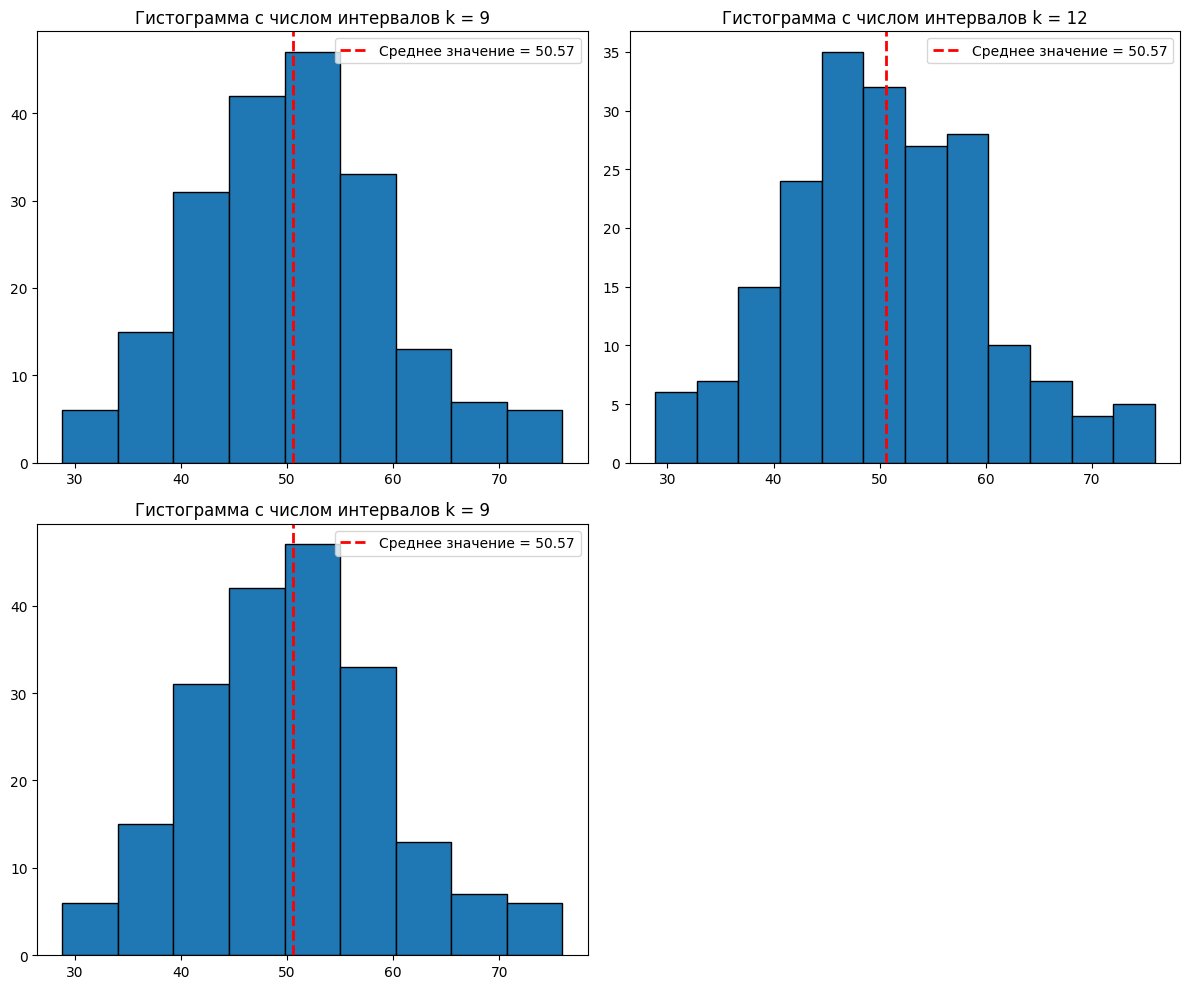


4.5. ОЦЕНКА МОМЕНТОВ ПО СГРУППИРОВАННОЙ ВЫБОРКЕ

Группировка по правилу Стерджеса (k = 9):
  Интервал              Частота  Середина интервала
  --------------------------------------------------
  [   28.81;    34.05)         6         31.43
  [   34.05;    39.29)        15         36.67
  [   39.29;    44.53)        31         41.91
  [   44.53;    49.77)        42         47.15
  [   49.77;    55.00)        47         52.38
  [   55.00;    60.24)        33         57.62
  [   60.24;    65.48)        13         62.86
  [   65.48;    70.72)         7         68.10
  [   70.72;    75.96)         6         73.34

Оценки по сгруппированной выборке:
  EX (среднее) = 50.5776
  DX (дисперсия, исправленная) = 85.1232
  СКО (по сгруппированным) = 9.2262

Сравнение с оценками по исходным данным:
  Среднее: 50.5689 (исходное) vs 50.5776 (группированное)
  Разница: 0.008683
  Дисперсия: 86.7702 (исходная) vs 85.1232 (группированная)
  Разница: 1.647054

4.6. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (γ = 0.95)



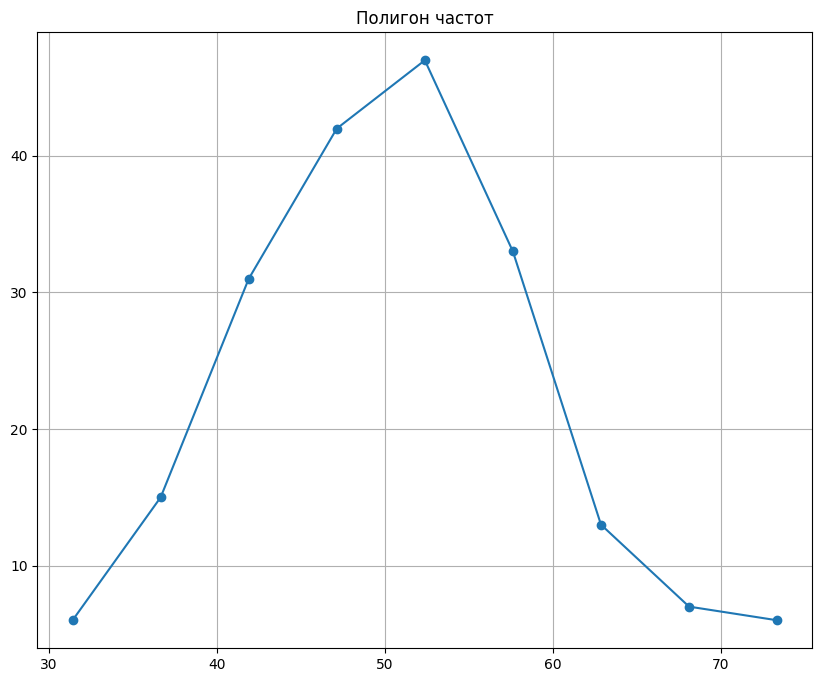

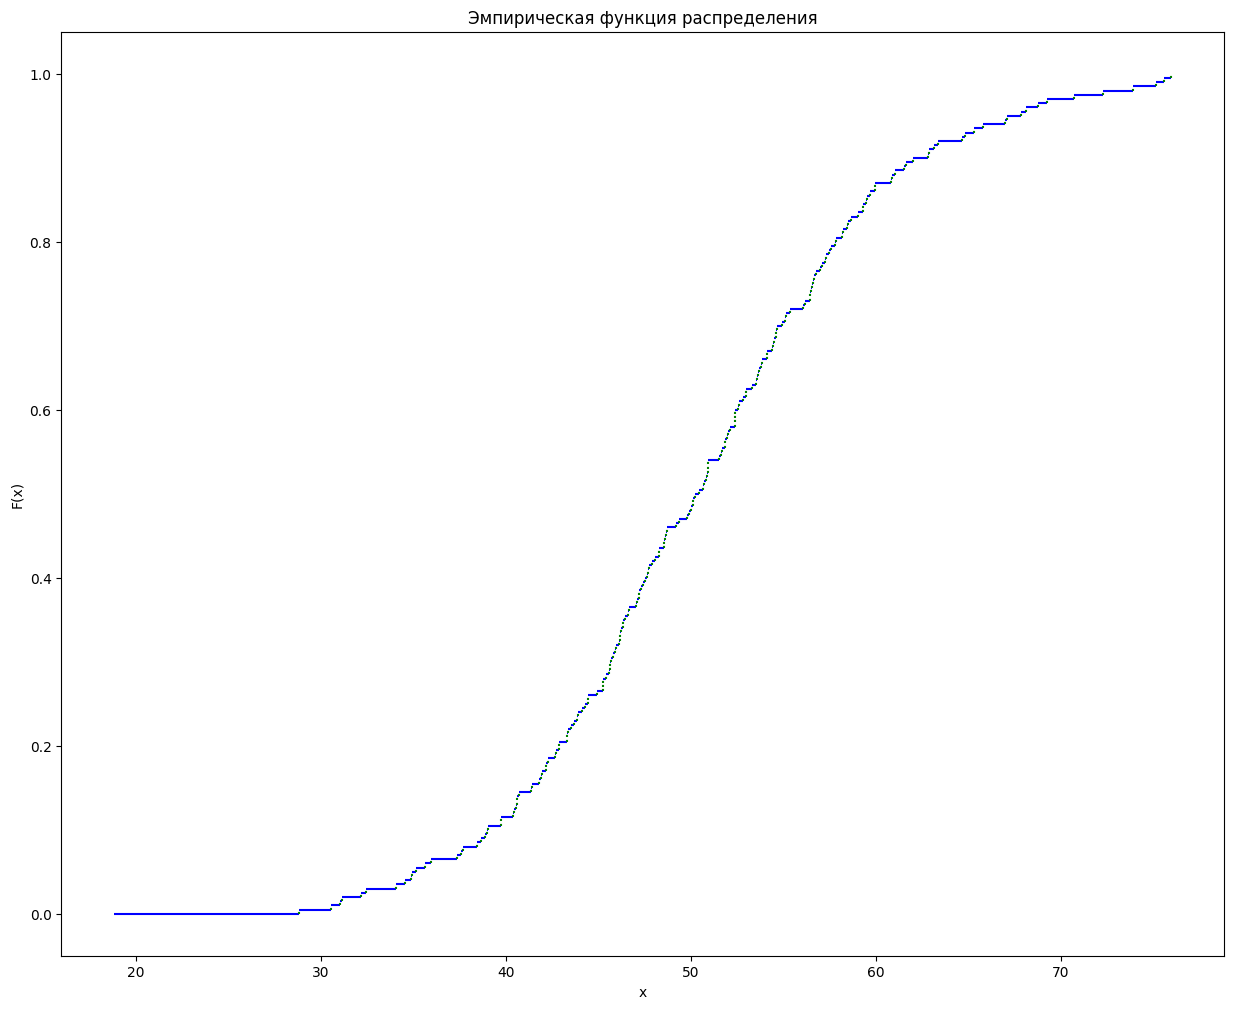

{'grouped_mean': np.float64(50.57758333333332),
 'grouped_var': np.float64(85.12315226673486),
 'ci_asymptotic': (np.float64(49.27792329123023),
  np.float64(51.85987670876978)),
 'ci_mu_exact': (np.float64(49.27002410767969),
  np.float64(51.867775892320324)),
 'ci_sigma_sq': (np.float64(71.95905089756937),
  np.float64(106.70257867170632))}

In [6]:
process_dataset(data_x1, "X1", is_normal=True)

## Вывод по столбцу $X1$

Выбранная модель - **Нормальное распределение** $N(a, \sigma)$

Малая ассиметрия, близость выборочного среднего и медианы, колокообразная форма гисторгамм - явные признаки нормального распредления. Среднее значение может использователься как оппорный элемент. Разброс умеренный. Выбросы незначительны

Доверительные интервалы:

Для $a$:
$[49.27;51.87]$ (узкий интервал)

Для $\sigma^2$:
$[71.96;106.70]$

Ширина интервалов:

- Интервалы для среднего узкие, оценки стабильные.
- Для дисперсии — умеренной ширины (нормально для этой задачи).

---

Объём выборки: n = 200

Выборочные оценки:
  Среднее:      x̄ = 49.10
  Дисперсия(смещенная):    s² = 166.74
  Ст. откл. (смещенное):    s = 12.91
  Дисперсия(несмещенная):    s² = 167.58
  Ст. откл. (несмещенное):    s = 12.95
  Медиана:      x̃ = 47.90
  Размах:       [26.8, 72.6]
  Квартили:
    q1 = np.float64(38.2875)
    q2 = np.float64(47.9)
    q3 = np.float64(59.175)
  Коэффициент ассиметрии:  γ = 0.1441839908968302  

Правило Скотта:
  Ширина интервала: h = 7.73
  Число интервалов: k = 6

Правило Фридмана–Диакониса:
  Ширина интервала: h = 7.14
  Число интервалов: k = 7

Правило Стерджеса:
  Число интервалов: k = 9



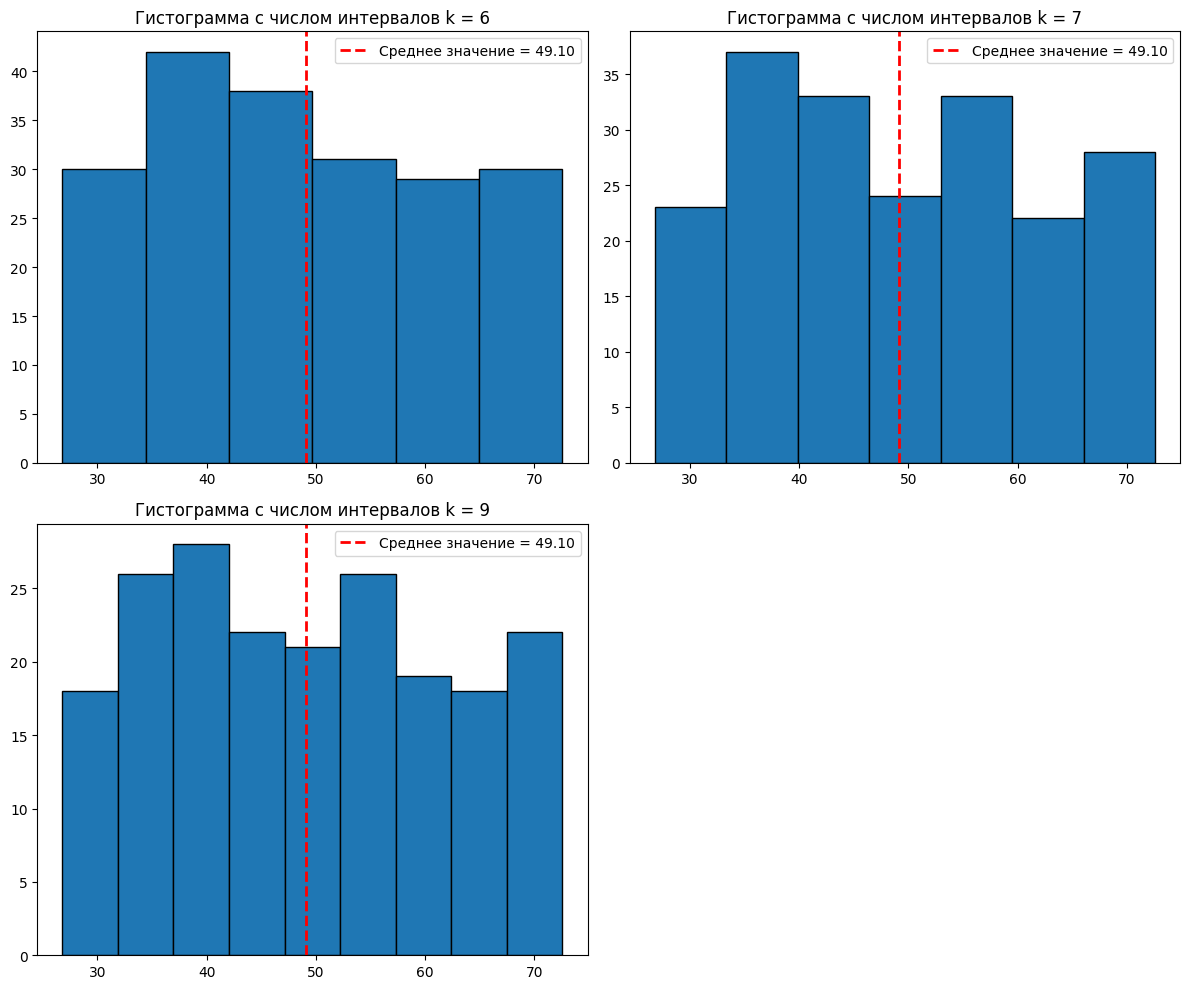


4.5. ОЦЕНКА МОМЕНТОВ ПО СГРУППИРОВАННОЙ ВЫБОРКЕ

Группировка по правилу Стерджеса (k = 9):
  Интервал              Частота  Середина интервала
  --------------------------------------------------
  [   26.80;    31.89)        18         29.34
  [   31.89;    36.97)        26         34.43
  [   36.97;    42.06)        28         39.51
  [   42.06;    47.14)        22         44.60
  [   47.14;    52.23)        21         49.68
  [   52.23;    57.31)        26         54.77
  [   57.31;    62.40)        19         59.86
  [   62.40;    67.48)        18         64.94
  [   67.48;    72.57)        22         70.03

Оценки по сгруппированной выборке:
  EX (среднее) = 49.1256
  DX (дисперсия, исправленная) = 164.9999
  СКО (по сгруппированным) = 12.8452

Сравнение с оценками по исходным данным:
  Среднее: 49.0995 (исходное) vs 49.1256 (группированное)
  Разница: 0.026089
  Дисперсия: 167.5754 (исходная) vs 164.9999 (группированная)
  Разница: 2.575501

4.6. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (γ = 0.9

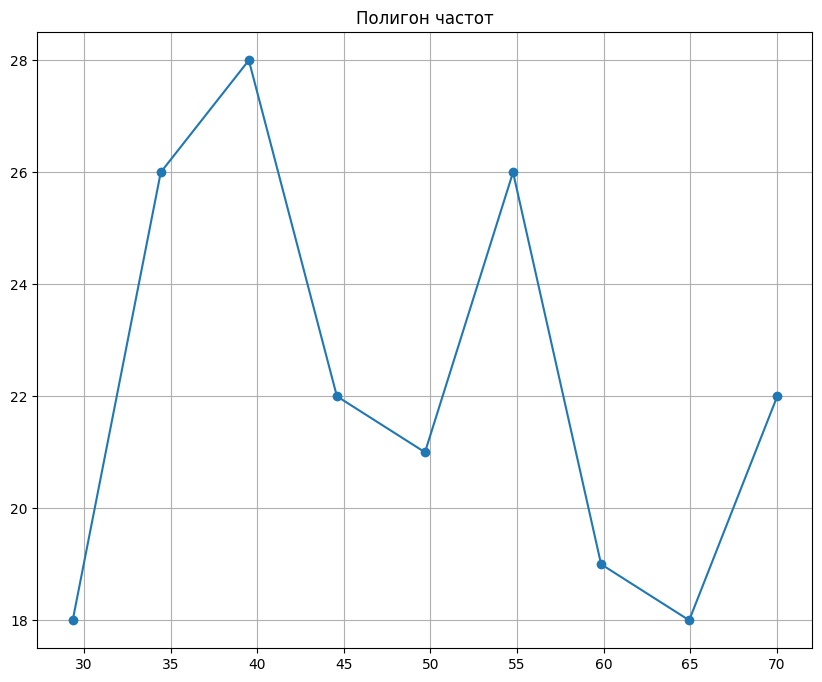

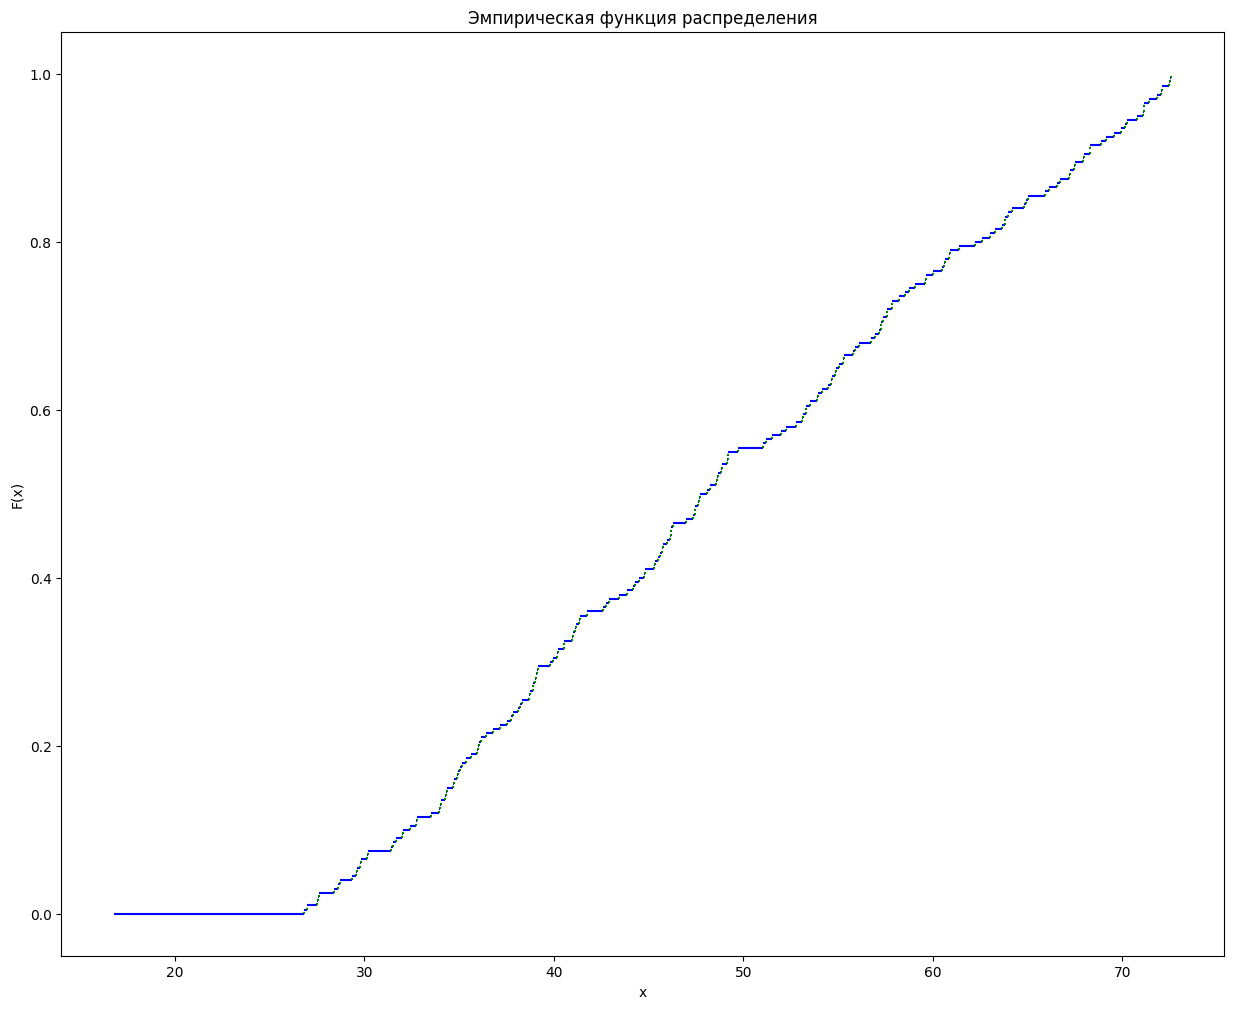

{'grouped_mean': np.float64(49.12558888888888),
 'grouped_var': np.float64(164.99994590123447),
 'ci_asymptotic': (np.float64(47.30543453442746),
  np.float64(50.893565465572536))}

In [7]:
process_dataset(data_x2, "X2")

## Вывод по столбцу $X2$

Выбранная модель - **Равномерное распределение** $U(a, b)$

Малая ассиметрия, остутсвие явного пика

$a = \min(X2) = 26.8$

$b = \max(X2) = 72.6$

Интервал для среднего:
$[47.31;50.89]$

Ширина интервалов:
- Интервал шире, чем у $X1$, но все равно достаточно небольшой
- Это указывает на меньшую точность оценок.

---

Объём выборки: n = 200

Выборочные оценки:
  Среднее:      x̄ = 79.81
  Дисперсия(смещенная):    s² = 3301.58
  Ст. откл. (смещенное):    s = 57.46
  Дисперсия(несмещенная):    s² = 3318.17
  Ст. откл. (несмещенное):    s = 57.60
  Медиана:      x̃ = 63.35
  Размах:       [22.5, 407.0]
  Квартили:
    q1 = np.float64(41.16)
    q2 = np.float64(63.35)
    q3 = np.float64(98.1825)
  Коэффициент ассиметрии:  γ = 1.9827323111946054  

Правило Скотта:
  Ширина интервала: h = 34.39
  Число интервалов: k = 12

Правило Фридмана–Диакониса:
  Ширина интервала: h = 19.50
  Число интервалов: k = 20

Правило Стерджеса:
  Число интервалов: k = 9



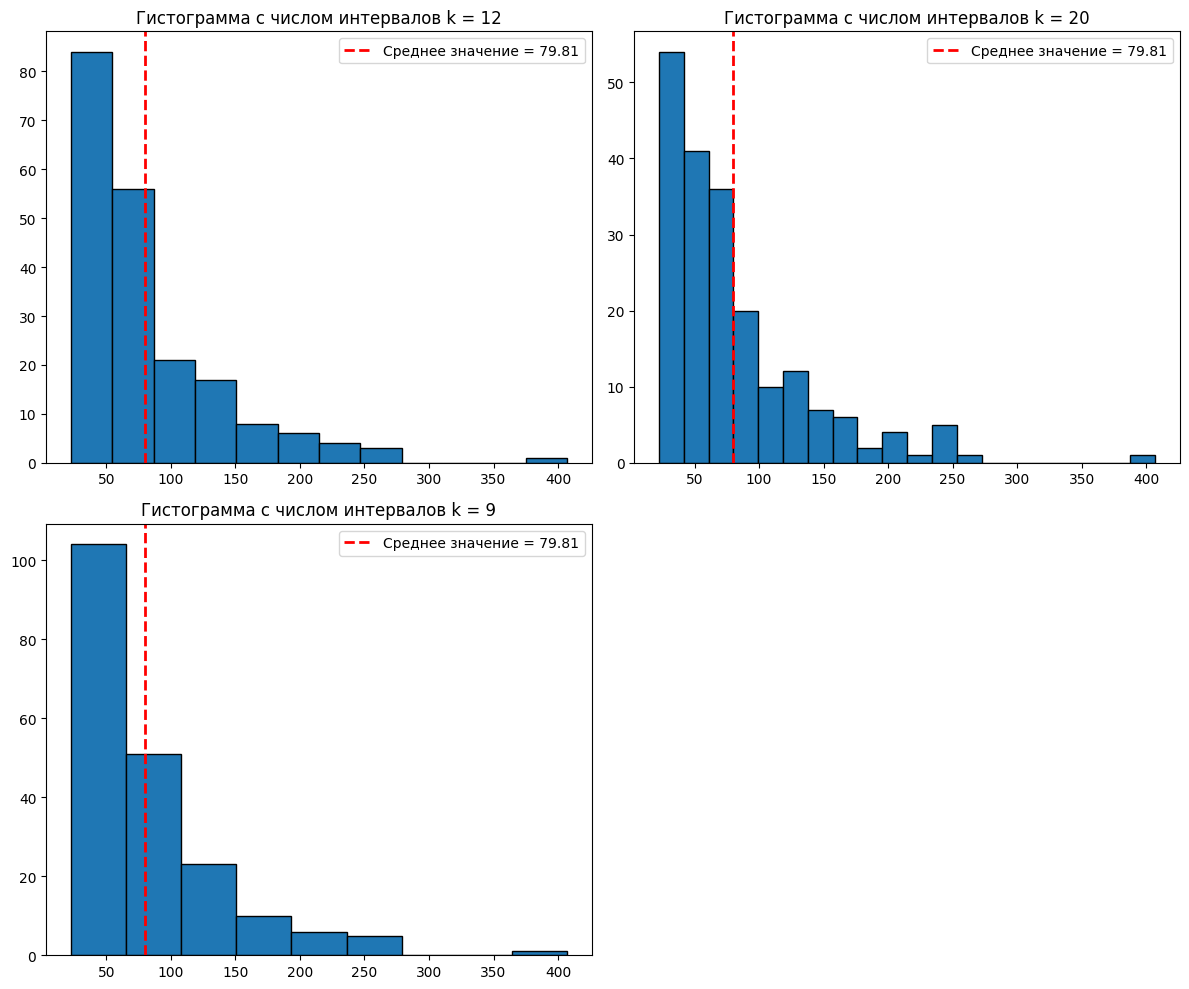


4.5. ОЦЕНКА МОМЕНТОВ ПО СГРУППИРОВАННОЙ ВЫБОРКЕ

Группировка по правилу Стерджеса (k = 9):
  Интервал              Частота  Середина интервала
  --------------------------------------------------
  [   22.47;    65.19)       104         43.83
  [   65.19;   107.92)        51         86.56
  [  107.92;   150.64)        23        129.28
  [  150.64;   193.37)        10        172.01
  [  193.37;   236.09)         6        214.73
  [  236.09;   278.82)         5        257.45
  [  278.82;   321.54)         0        300.18
  [  321.54;   364.27)         0        342.90
  [  364.27;   406.99)         1        385.63

Оценки по сгруппированной выборке:
  EX (среднее) = 83.1387
  DX (дисперсия, исправленная) = 3198.7230
  СКО (по сгруппированным) = 56.5573

Сравнение с оценками по исходным данным:
  Среднее: 79.8089 (исходное) vs 83.1387 (группированное)
  Разница: 3.329811
  Дисперсия: 3318.1661 (исходная) vs 3198.7230 (группированная)
  Разница: 119.443127

4.6. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (γ 

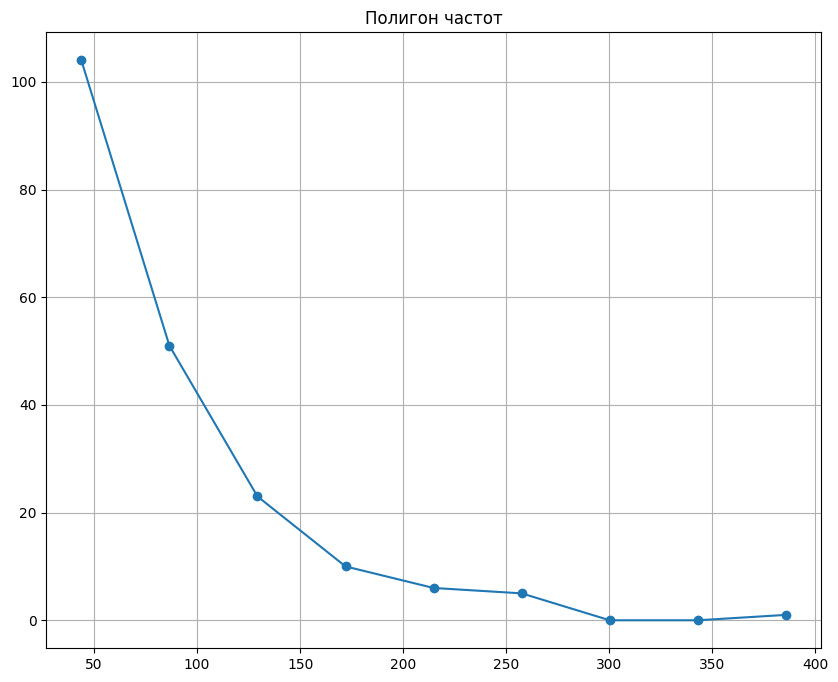

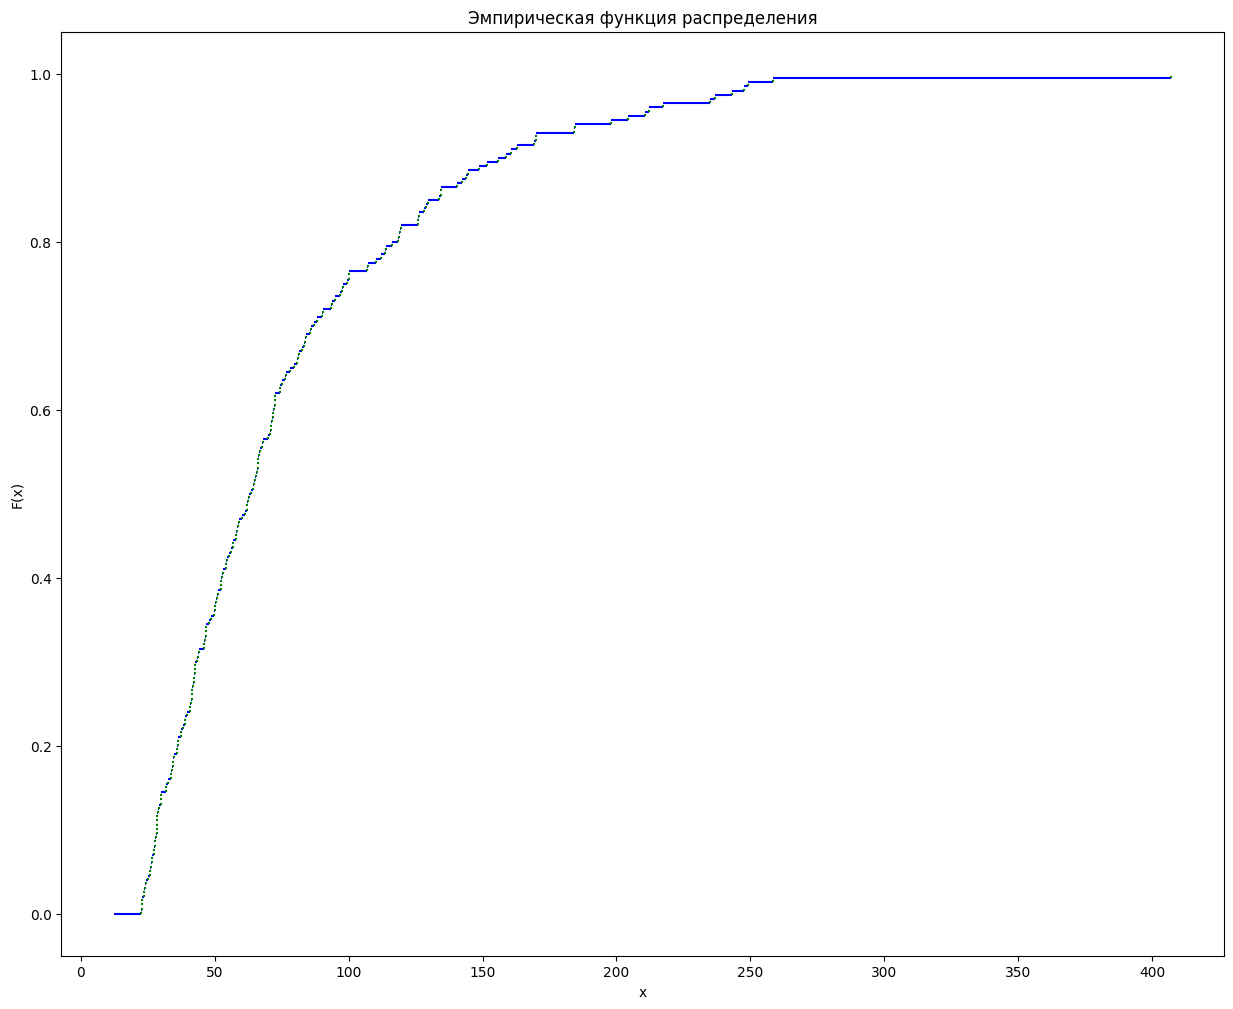

{'grouped_mean': np.float64(83.13871111111112),
 'grouped_var': np.float64(3198.7229625341524),
 'ci_asymptotic': (np.float64(71.82560544448458),
  np.float64(87.79219455551544))}

In [8]:
process_dataset(data_x3, "X3")

## Вывод по столбцу $X3$

Выбранная модель - **Экспоненциальное распределение** $\operatorname{Exp}(\lambda, c)$

Сильная правая ассиметрия, дланный правый хвост, сильное различие медианы и среднего

Оценённые параметры:

$c \approx \min(X3) = 22.5$

$\lambda \approx \frac{1}{\bar{x} - c} = 0.0174$

Доверительный интервал для среднего:
$[71.83;87.79]$

Ширина интервалов:
- Интервал очень широкий, что говорит о высокой неопределённости.
- Это связано с большой дисперсией и асимметрией.


---

# Итоговый вывод по РГР №1

### 1. Идентификация законов распределения
В ходе выполнения работы был проведен статистический анализ четырех наборов данных объема $$n = 200$$. На основании графического анализа и сопоставления выборочных характеристик с теоретическими, были определены следующие модели:

* **Столбец $X_1$ — Нормальное распределение ($N_{a, \sigma}$):**
    * Среднее $$\bar{x} = 50.57$$и медиана$$\tilde{x} = 50.34$$ практически совпадают. Коэффициент асимметрии близок к нулю ($$\gamma \approx 0.27$$), что характерно для симметричного колоколообразного распределения.
* **Столбец $X_2$ — Равномерное распределение ($U_{a, b}$):**
    * Распределение симметрично ($$\gamma \approx 0.14$$), среднее $$\bar{x} = 49.10$$находится в центре размаха$$[26.8, 72.6]$$. Отсутствие ярко выраженной моды указывает на равномерный закон.
* **Столбец $X_3$ — Экспоненциальное распределение со сдвигом ($Exp_{\lambda, c}$):**
    * Наблюдается высокая положительная асимметрия ($$\gamma \approx 1.98$$) и значительный разрыв между медианой ($$63.35$$) и максимумом ($$407.0$$), что указывает на «тяжелый хвост» справа.
* **Столбец $X_4$ — Неоднородная выборка (смесь распределений):**
    * Несмотря на умеренную асимметрию, среднее ($$71.30$$) значительно удалено от медианы ($$46.76$$). Большая дисперсия ($$s^2 \approx 1392$$) и визуальная бимодальность гистограммы говорят о наличии двух групп данных.

### 2. Оценивание параметров и правила группировки
Для каждого набора данных было проведено сравнение правил определения количества интервалов ($k$):
* **Правило Стерджеса** стабильно предлагает $$k = 9$$, что является классическим подходом для данного объема выборки.
* **Правило Фридмана–Диакониса** более чувствительно к разбросу: для столбца $X_3$ с большим количеством выбросов оно предложило $$k = 20$$, что позволяет лучше детализировать структуру «хвоста» распределения.

### 3. Сравнение методов оценивания
* Для **нормального распределения** ($X_1$) оценки параметров методом моментов (ММ) и максимального правдоподобия (ММП) совпадают ($$\hat{a} = 50.57$$).
* Для **равномерного** ($X_2$) и **экспоненциального** ($X_3$) распределений метод ММП является более предпочтительным, так как он минимизирует влияние отклонений, используя границы выборки ($$\min$$и$$\max$$) для оценки параметров сдвига.

### 4. Доверительные интервалы и точность
Построенные доверительные интервалы с уровнем доверия $$\gamma = 0.95$$ для математического ожидания показали, что:
* Точность оценивания высока, так как стандартная ошибка среднего $$\hat{\sigma}/\sqrt{n}$$ невелика по сравнению с величиной самих значений.
* С надежностью 95% можно утверждать, что истинные значения параметров лежат в рассчитанных диапазонах.

### 5. Резюме по неоднородности ($X_4$)
Анализ столбца $X_4$ подтвердил, что стандартные статистические показатели (среднее, дисперсия) не дают адекватного представления о структуре данных при наличии бимодальности. Среднее значение $$71.30$$ не является типичным ни для одного из скоплений данных, что требует разделения выборки на подгруппы перед дальнейшим анализом.

---
